In [1]:
%matplotlib inline

# Bayesian analysis

The previous tutorials demonstrate how to obtain *maximum-likelihood* estimates of the parameters of a model by minimising $\chi^2$.
An alternative, and often more informative, view of the same problem is provided by a **Bayesian** analysis, in which the goal is to characterise the full *posterior distribution* over the parameters given the data.

Recall Bayes' theorem,

$$
p(\theta \mid d) \propto p(d \mid \theta)\, p(\theta),
$$ (bayes)

where $\theta$ are the model parameters, $d$ is the observed data, $p(d \mid \theta)$ is the likelihood, and $p(\theta)$ is the prior. In `easyscience`, the `min`/`max` bounds of a `Parameter` are interpreted as a **uniform prior**, and a Gaussian likelihood is constructed from the data and supplied weights.

`easyscience` exposes a Bayesian Markov-chain Monte Carlo (MCMC) sampler through the `Sampler` class.  Under the hood this uses BUMPS' DREAM sampler, so the underlying minimizer must be switched to BUMPS.

```{note}
This tutorial focuses on Bayesian analysis with a simple QENS model for illustration. For dedicated QENS fitting with more sophisticated models, consider using [`EasyDynamics`](https://github.com/easyscience/easydynamics).
```

### When should you use a Bayesian analysis?

A maximum-likelihood estimate (MLE) gives you a single best-fit value with a symmetric uncertainty, which is fast and often sufficient. A Bayesian analysis becomes valuable when:

- **Your uncertainties are asymmetric** &mdash; MLE error bars assume the parameter distribution is Gaussian, which is not always true. The posterior samples capture skew naturally.
- **You have prior knowledge** &mdash; if you know from physics that a parameter *must* lie in a certain range, encoding that as a prior ($p(\theta)$) is more principled than simply clamping bounds after the fit.
- **You care about parameter correlations** &mdash; the joint posterior (shown in the corner plot below) reveals trade-offs between parameters that a single covariance matrix can miss.
- **You want to propagate uncertainty to predictions** &mdash; with the posterior in hand, you can compute credible bands on any function of the parameters (see the posterior-predictive band section) without linearised error propagation.

The trade-off is computational cost: MCMC requires thousands of model evaluations, whereas an MLE fit may converge in dozens. For the simple 4-parameter model used here the difference is negligible, but for expensive models it is worth starting with MLE and only switching to MCMC when you need the richer output.

In this tutorial we re-use the QENS dataset and the Lorentzian-with-resolution model from the [Fitting QENS](fitting-qens.ipynb) tutorial, but instead of returning a single best-fit value with a symmetric error bar we will draw thousands of samples from the posterior.

## Load the data

We load the same simulated QENS dataset that was used in the previous tutorial.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def fetch_data(name: str, known_hash: str) -> str:
    """
    Fetch pre-prepared data from a remote source and return the path to the file.
    """
    import pooch

    return pooch.retrieve(
        url=f'https://public.esss.dk/groups/scipp/dmsc-summer-school/2025/{name}',
        known_hash=known_hash,
    )

In [4]:
filename = fetch_data(
    '4-reduction/energy_transfer_QENS_unknown_quasi_elastic_many_neutrons.dat',
    known_hash='sha256:e49fa9a1d2ef5eeb714524903e8ffa9de6616e5a299a799cbb0b2f3ee8fd459a',
)


def load(filename: str):
    """Load three-column text data (x, y, error) and filter NaN values.

    The file is expected to be a space-separated three-column text file
    (commonly ``.dat`` or ``.txt``) with columns: x, y, error (1σ).
    """
    x, y, error = np.loadtxt(filename, unpack=True)
    selection = np.isfinite(y)
    return x[selection], y[selection], error[selection]


omega, intensity_obs, intensity_error = load(filename)

# Restrict to the region of interest, as in the QENS tutorial.
selection = (omega > -0.06) & (omega < 0.06)
omega, intensity_obs, intensity_error = (
    omega[selection],
    intensity_obs[selection],
    intensity_error[selection],
)

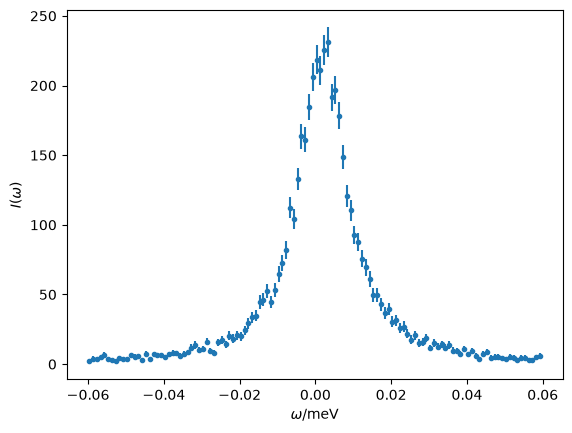

In [5]:
fig, ax = plt.subplots()
ax.errorbar(omega, intensity_obs, intensity_error, fmt='.')
ax.set(xlabel='$\\omega$/meV', ylabel='$I(\\omega)$')
plt.show()

## Defining parameters with priors

Create four `Parameter` objects, for the area $A$, $\gamma$, $\omega_0$ and $\sigma$. The `min` and `max` arguments define a **uniform prior** on each parameter &mdash; the sampler will only consider values inside this range and will treat every value inside the range as equally plausible *a priori*.

| Parameter | Initial Value | Min | Max |
| --- | --- | --- | --- |
| $A$ (area) | 10 | 1 | 100 |
| $\gamma$ | 8.0 &times; 10<sup>-3</sup> | 1.0 &times; 10<sup>-4</sup> | 1.0 &times; 10<sup>-2</sup> |
| $\omega_0$ | 1.0 &times; 10<sup>-3</sup> | 0 | 2.0 &times; 10<sup>-3</sup> |
| $\sigma$ | 1.0 &times; 10<sup>-3</sup> | 1.0 &times; 10<sup>-5</sup> | 1.0 &times; 10<sup>-1</sup> |


In [6]:
from easyscience import Parameter

area = Parameter(name='area', value=10, fixed=False, min=1, max=100)
gamma = Parameter(name='gamma', value=8e-3, fixed=False, min=1e-4, max=1e-2)
omega_0 = Parameter(name='omega_0', value=1e-3, fixed=False, min=0, max=2e-3)
sigma = Parameter(name='sigma', value=1e-3, fixed=False, min=1e-5, max=1e-1)

## The model

We re-use the convolution of a Lorentzian with a Gaussian resolution function from the QENS tutorial:

$$
I(\omega) = \frac{A\gamma}{\pi\big[(\omega - \omega_0)^2 + \gamma^2\big]} \;\ast\; \mathcal{N}(0, \sigma),
$$ (model)

where $A$ is a scale factor (area), $\gamma$ is the Lorentzian half-width at half-maximum, $\omega_0$ is the centre offset and $\sigma$ is the width of the Gaussian resolution kernel.

You might want to look at other QENS models, as implemented in the [EasyDynamics](https://github.com/easyscience/dynamics-lib) library.

```{note}
The convolution below uses `np.convolve(..., 'same')` for simplicity. In `'same'` mode, `numpy` pads the signal edges with zeros, which can introduce small artefacts at the boundaries. Because our Gaussian kernel ($\sigma \approx 10^{-3}$) is much narrower than the data range ($\pm 0.06$ meV), these edge effects are negligible here. For production work with broader kernels, consider `scipy.signal.convolve` with an explicit boundary mode such as `'reflect'` or `'nearest'`.
```


In [7]:
from scipy.stats import norm


def lorentzian(x: np.ndarray) -> np.ndarray:
    return area.value / np.pi * gamma.value / ((x - omega_0.value) ** 2 + gamma.value**2)


def intensity_model(x: np.ndarray) -> np.ndarray:
    gauss = norm(0, sigma.value).pdf(x)
    gauss /= gauss.sum()
    return np.convolve(lorentzian(x), gauss, 'same')

## Maximum-likelihood fit (optional, but recommended)

Perform a quick maximum-likelihood fit. This is **not** a prerequisite for sampling: `Sampler`
needs a *configured* `Fitter`, not a *fitted* one, and you can sample straight from the initial
parameter values.

It is worth doing anyway, for two reasons:

1. It lets us compare the central tendency of the posterior against the classical best-fit values.
2. It gives the chain a much better starting point. DREAM seeds its entire starting population
   inside a tiny ball around whatever the parameter values happen to be at the time (BUMPS' default
   `init='eps'`), so sampling from fitted values begins in the right region of parameter space and
   needs less burn-in to reach the typical set. Starting from a poor initial guess is not wrong, but
   expect to burn for longer.

In [8]:
from easyscience import Fitter
from easyscience import ObjBase

parameter_container = ObjBase(name='params', A=area, gamma=gamma, omega_0=omega_0, sigma=sigma)

mle_fitter = Fitter(parameter_container, intensity_model)
mle_result = mle_fitter.fit(x=omega, y=intensity_obs, weights=1 / intensity_error)

print(f'A = {area.value:.4g}')
print(f'gamma = {gamma.value:.4g}')
print(f'omega_0 = {omega_0.value:.4g}')
print(f'sigma = {sigma.value:.4g}')

ObjBase is deprecated and will be removed in a future version. Please migrate to ModelBase.


A = 5.227
gamma = 0.007161
omega_0 = 0.001142
sigma = 0.001087


## Drawing posterior samples with DREAM

We now draw samples from the posterior distribution $p(\theta \mid d)$ using the BUMPS DREAM (DiffeRential Evolution Adaptive Metropolis) algorithm. DREAM is an ensemble MCMC method that runs multiple chains in parallel and automatically tunes the proposal distribution.

DREAM only works with the BUMPS minimizer. We reuse the ``mle_fitter`` created above — any configured `Fitter` would do, and it does not have to have been fitted — switch it to BUMPS, and create a `Sampler` instance bound to the fitter and data. Calling `sampler.sample()` returns a `SamplingResults` object with the following attributes:

- `draws`: a `(n_samples, n_parameters)` array of posterior samples: each **row** is one complete draw from the joint posterior (one value for every parameter simultaneously), and each **column** holds all sampled values for a single parameter. Note this is a *trimmed* view of the chain rather than the raw buffer, so `n_samples` is smaller than `samples / thin` &mdash; see the note under [Extend the chain](#extend-the-chain-and-check-convergence);
- `param_names`: the unique names of the parameters, in the same column order as `draws`;
- `state`: the underlying BUMPS `MCMCDraw` object, useful for advanced diagnostics;
- `logp`: the log-posterior of each retained sample.

The key sampling parameters are:

- `samples` (10000): the number of raw samples to draw across all chains, *before* thinning. This is a guaranteed minimum rather than an exact count: DREAM advances in blocks of 10 generations (one generation = one draw per chain) and stops at the first block boundary at or past `samples`;
- `burn` (500): the number of initial *burn-in* generations to discard &mdash; the sampler needs time to find the typical set of the posterior, and early samples are not representative. Note this counts generations, not raw samples, so `burn=500` discards `500 × n_chains` raw samples;
- `thin` (2): the *thinning* interval &mdash; only every second generation is kept, which reduces autocorrelation between consecutive draws;

First, we switch to the BUMPS minimizer:

In [9]:
from easyscience import AvailableMinimizers

mle_fitter.switch_minimizer(AvailableMinimizers.Bumps)

In [10]:
from easyscience.fitting import Sampler

sampler = Sampler(mle_fitter, omega, intensity_obs, weights=1 / intensity_error)
results = sampler.sample(samples=10000, burn=500, thin=2)

print(f'Drew {results.draws.shape[0]} samples for {results.draws.shape[1]} parameters.')
print('parameters:', results.param_names)

Drew 4040 samples for 4 parameters.
parameters: ['Parameter_0', 'Parameter_1', 'Parameter_2', 'Parameter_3']


## Convergence diagnostics

Before we trust the posterior samples, we should check that the MCMC chains have **converged** &mdash; that is, the sampler has found the typical set of the posterior and is no longer drifting. Two simple visual checks are:

1. **Trace plot** &mdash; plot the sampled parameter values against the sample index. A well-converged chain looks like a "hairy caterpillar": it fluctuates around a stable mean with no long-term trends.
2. **Log-posterior plot** &mdash; the log-posterior $\log p(\theta \mid d)$ should also stabilise after burn-in. If it is still climbing at the end of the run, the sampler has not yet converged.

The `logp` array returned by `sample` contains the log-posterior for every *retained* sample (i.e. *after* burn-in and thinning). This means a flat `logp` trace is exactly what we want to see.


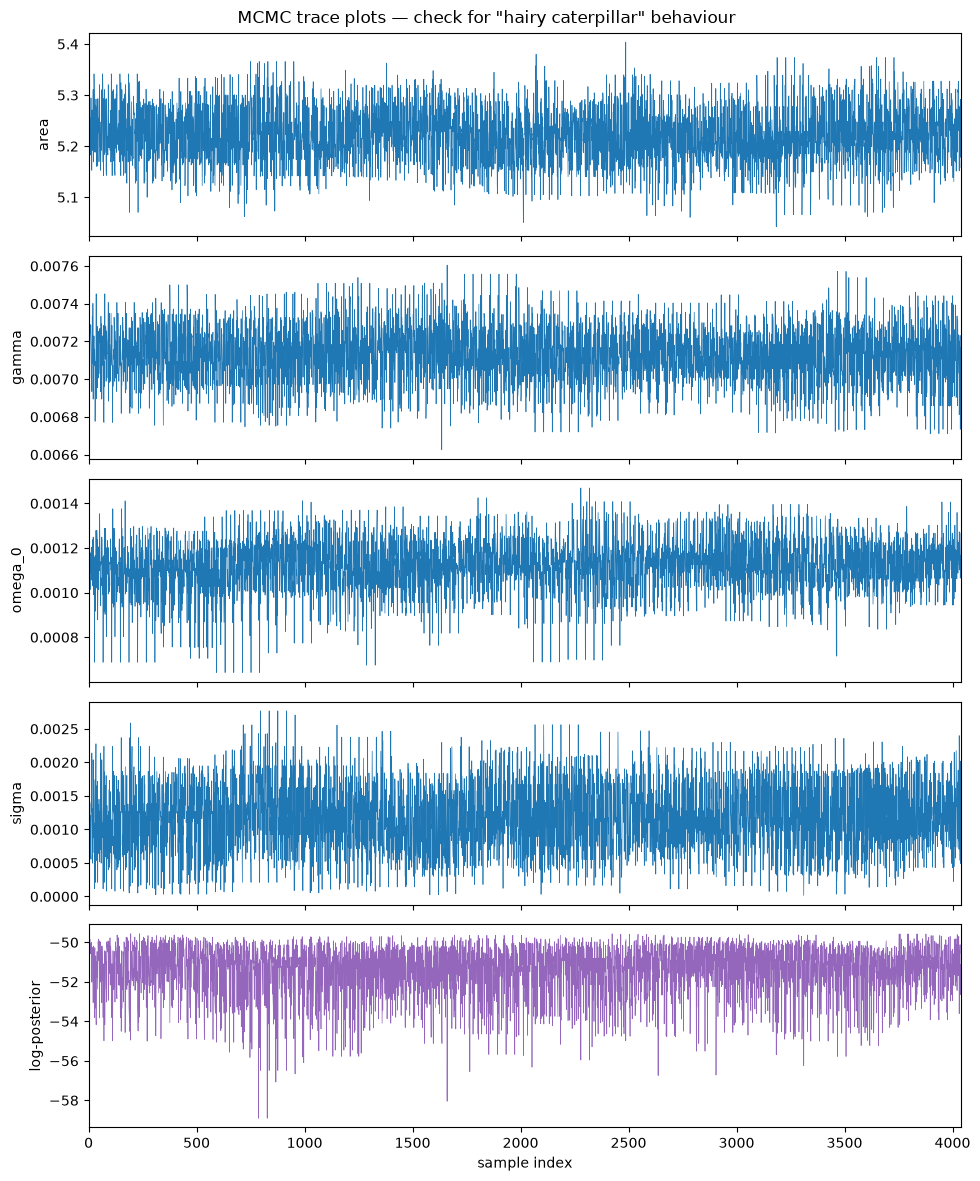

In [11]:
draws = results.draws
logp = results.logp
name_to_col = {name: idx for idx, name in enumerate(results.param_names)}


def column_for(parameter):
    return draws[:, name_to_col[parameter.unique_name]]


fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

# Trace plots for each parameter
for ax, (label, par) in zip(
    axes[:4],
    (('area', area), ('gamma', gamma), ('omega_0', omega_0), ('sigma', sigma)),
):
    ax.plot(column_for(par), lw=0.5)
    ax.set_ylabel(label)
    ax.set_xlim(0, len(draws) - 1)

# Log-posterior trace
axes[4].plot(logp, lw=0.5, color='C4')
axes[4].set_ylabel('log-posterior')
axes[4].set_xlabel('sample index')

fig.suptitle('MCMC trace plots — check for "hairy caterpillar" behaviour')
fig.tight_layout()
plt.show()

## Posterior summaries

Summarise each marginal posterior by its **median** and the 16th/84th percentiles, which together give an asymmetric 68% credible interval. Compare these with the MLE values you obtained above.


**Why might the Bayesian median differ from the MLE?**
The MLE finds the single point that maximises the likelihood, while the Bayesian median is the central value of the *posterior* &mdash; which also accounts for the prior $p(\theta)$. If a parameter's posterior is skewed (asymmetric), the median and the mode (which approximates the MLE) will not coincide. The table below shows both so you can spot any such differences.


Note that the columns of `results.draws` are ordered by `results.param_names` (which use the parameters' `unique_name`), so it is worth building a small helper to look up a column by friendly name.

In [12]:
summary_rows = []
for label, par in (
    ('area', area),
    ('gamma', gamma),
    ('omega_0', omega_0),
    ('sigma', sigma),
):
    col = column_for(par)
    lo, med, hi = np.percentile(col, [16, 50, 84])
    summary_rows.append((label, med, med - lo, hi - med, par.value))

print(f'{"param":<8s} {"median":>12s} {"16th":>12s} {"84th":>12s} {"MLE":>12s}')
for label, med, low, high, mle in summary_rows:
    print(f'{label:<8s} {med:12.4g} {low:12.4g} {high:12.4g} {mle:12.4g}')

param          median         16th         84th          MLE
area            5.219      0.05187       0.0607        5.337
gamma        0.007139    0.0001568    0.0001371     0.007595
omega_0      0.001127    0.0001155     0.000107    0.0008515
sigma        0.001175    0.0005355    0.0005734    0.0004605


## Visualise the joint posterior

Marginal summaries hide correlations between parameters. A *corner plot* (a triangular grid of pairwise scatter plots and 1-D histograms) is the standard way to display them. Below we build one with plain `matplotlib`. To produce a publication-quality version, use plotting packages such as [`corner`](https://corner.readthedocs.io/) which can generate corner plots with a single function call.


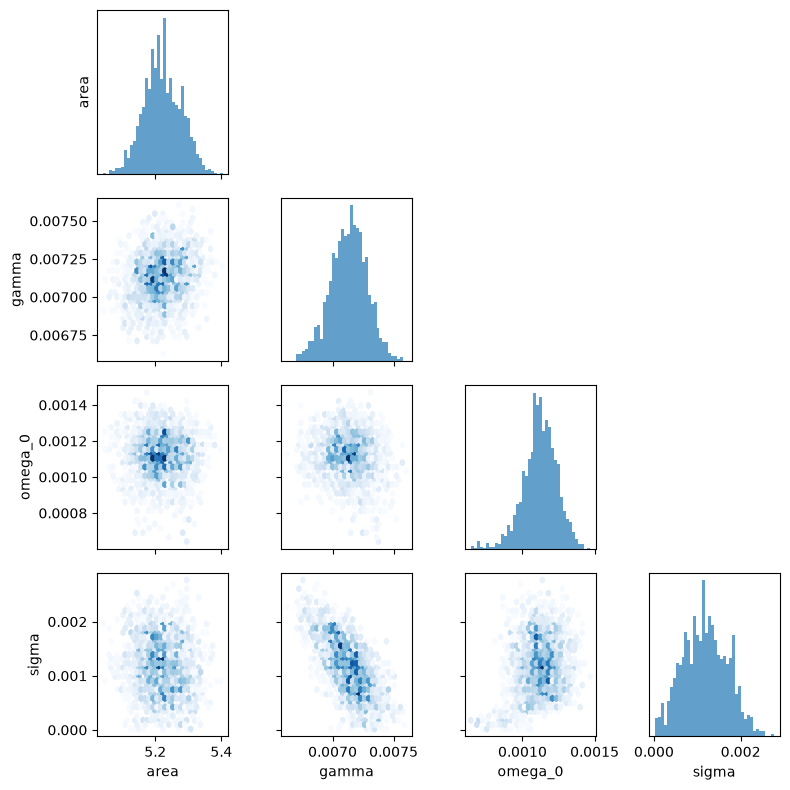

In [13]:
labels = ['area', 'gamma', 'omega_0', 'sigma']
cols = np.column_stack([column_for(p) for p in (area, gamma, omega_0, sigma)])
n = len(labels)

fig, axes = plt.subplots(n, n, figsize=(8, 8))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
            continue
        if i == j:
            ax.hist(cols[:, i], bins=40, color='C0', histtype='stepfilled', alpha=0.7)
            ax.set_yticks([])
        else:
            ax.hexbin(cols[:, j], cols[:, i], gridsize=30, cmap='Blues', mincnt=1)
        if i == n - 1:
            ax.set_xlabel(labels[j])
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
fig.tight_layout()
plt.show()

## Posterior-predictive band

With the full posterior in hand we can propagate uncertainty through the model without assuming Gaussianity. Unlike error propagation from an MLE fit &mdash; which assumes parameters are normally distributed and independent &mdash; the posterior draws naturally capture any skew, heavy tails, and correlations between parameters. Below we pick a few hundred random draws, evaluate the model at each, and plot the resulting 95% credible band alongside the data.


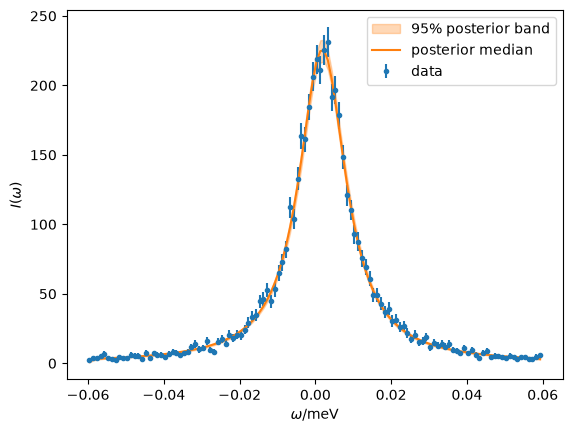

In [14]:
rng = np.random.default_rng(seed=0)
n_draws = 300
indices = rng.choice(draws.shape[0], size=n_draws, replace=False)

predictions = np.empty((n_draws, omega.size))
saved = {p.unique_name: p.value for p in (area, gamma, omega_0, sigma)}
try:
    for k, idx in enumerate(indices):
        area.value = draws[idx, name_to_col[area.unique_name]]
        gamma.value = draws[idx, name_to_col[gamma.unique_name]]
        omega_0.value = draws[idx, name_to_col[omega_0.unique_name]]
        sigma.value = draws[idx, name_to_col[sigma.unique_name]]
        predictions[k] = intensity_model(omega)
finally:
    for p in (area, gamma, omega_0, sigma):
        p.value = saved[p.unique_name]

lo = np.percentile(predictions, 2.5, axis=0)
hi = np.percentile(predictions, 97.5, axis=0)
mid = np.percentile(predictions, 50, axis=0)

fig, ax = plt.subplots()
ax.errorbar(omega, intensity_obs, intensity_error, fmt='.', label='data')
ax.fill_between(omega, lo, hi, color='C1', alpha=0.3, label='95% posterior band')
ax.plot(omega, mid, '-', color='C1', label='posterior median')
ax.set(xlabel='$\\omega$/meV', ylabel='$I(\\omega)$')
ax.legend()
plt.show()

## Extend the chain and check convergence

The original run asked for ``samples=10000`` with ``thin=2``. Here we **extend the
chain by 5000 more raw samples** using ``sampler.extend()`` — DREAM continues from
the previous in-memory state instead of starting from scratch.

``sampler.extend(additional_samples=5000)`` does the ring-buffer arithmetic for you
automatically: it reads the number of stored generations from the saved state and
sizes the new buffer to ``old_generations + additional_samples``, so no existing
draws are dropped from the buffer.

```{note}
`results.draws` grows by less than `additional_samples / thin`, for two unrelated
reasons.

First, BUMPS post-processes the chain before returning it: with the default
`trim=True` it re-runs a burn-point detector over the whole extended chain and
returns only the part after the detected burn point, minus any chains flagged as
outliers. The detector runs anew on every `sample()` and `extend()` call, so the
retained count is not deterministic and can even shrink. This is unrelated to
`burn=500`: `extend()` resumes with `burn=0`.

Second, `samples` is a minimum, not an exact count. DREAM advances in blocks of
10 generations (one generation = one draw per chain - this model has 4 parameters
and the default population scale of 10, hence 40 chains) and only checks its
stopping condition between blocks, so the chain grows by `additional_samples`
rounded up to a multiple of `10 × n_chains` raw draws. Here that is
5000 -> 13 blocks of 400 -> 5200 raw draws, i.e. 2600 retained rows at `thin=2`.

The full chain is always available via
`results.state.draw(portion=1.0, outliers=True)`; pass
`sampler_kwargs={'trim': False}` to disable the trimming altogether.
```

After the extension we compare the posterior summaries and check convergence with
Gelman-Rubin R-hat.

In [15]:
# Extend the existing chain by 5000 more raw samples.
# extend() handles the ring-buffer arithmetic automatically.
extended_results = sampler.extend(additional_samples=5000, thin=2)


def n_full_chain(res):
    """Rows in the whole chain, before BUMPS' automatic trimming."""
    return res.state.draw(portion=1.0, outliers=True).points.shape[0]


print(f'{"chain":<10s} {"trimmed":>9s} {"full":>9s}')
print('-' * 30)
print(f'{"original":<10s} {results.draws.shape[0]:9d} {n_full_chain(results):9d}')
print(
    f'{"extended":<10s} {extended_results.draws.shape[0]:9d} {n_full_chain(extended_results):9d}'
)

grew_by = n_full_chain(extended_results) - n_full_chain(results)
print(f'\nThe full chain grew by {grew_by} draws: the {5000 // 2} we asked for')
print('(additional_samples / thin), rounded up to whole DREAM blocks of 10 generations.')
print('The "trimmed" column is what results.draws exposes: a view, not the chain.')

chain        trimmed      full
------------------------------
original        4040      5000
extended        6200      7600

The full chain grew by 2600 draws: the 2500 we asked for
(additional_samples / thin), rounded up to whole DREAM blocks of 10 generations.
The "trimmed" column is what results.draws exposes: a view, not the chain.


In [16]:
# Build helpers to look up parameter columns.
name_to_col_ext = {name: idx for idx, name in enumerate(extended_results.param_names)}
name_to_col_orig = {name: idx for idx, name in enumerate(results.param_names)}


def col_orig(par):
    return results.draws[:, name_to_col_orig[par.unique_name]]


def col_ext(par):
    return extended_results.draws[:, name_to_col_ext[par.unique_name]]


# Side-by-side posterior summary: the original chain vs the full extended set.
lbl_orig = f'original ({results.draws.shape[0]})'
lbl_ext = f'extended ({extended_results.draws.shape[0]})'
print(f'{"param":<10s} {"metric":>8s} {lbl_orig:>18s} {lbl_ext:>18s}  diff')
print('-' * 70)
for label, par in (('area', area), ('gamma', gamma), ('omega_0', omega_0), ('sigma', sigma)):
    c_first = col_orig(par)
    c_full = col_ext(par)
    for metric, fn in [
        ('mean', np.mean),
        ('std', np.std),
        ('q2.5%', lambda c: np.percentile(c, 2.5)),
        ('q50%', lambda c: np.percentile(c, 50)),
        ('q97.5%', lambda c: np.percentile(c, 97.5)),
    ]:
        vf = fn(c_first)
        vx = fn(c_full)
        diff = vx - vf
        print(f'{label:<10s} {metric:>8s} {vf:18.4g} {vx:18.4g} {diff:+.2e}')

param        metric    original (4040)    extended (6200)  diff
----------------------------------------------------------------------
area           mean              5.221              5.223 +2.45e-03
area            std            0.05519            0.05507 -1.26e-04
area          q2.5%              5.113              5.114 +1.62e-03
area           q50%              5.219              5.222 +3.20e-03
area         q97.5%              5.327              5.331 +3.89e-03
gamma          mean            0.00713           0.007137 +7.03e-06
gamma           std          0.0001502          0.0001527 +2.49e-06
gamma         q2.5%           0.006819           0.006812 -7.14e-06
gamma          q50%           0.007139           0.007146 +7.30e-06
gamma        q97.5%            0.00742            0.00742 -1.31e-09
omega_0        mean           0.001121            0.00112 -1.26e-06
omega_0         std          0.0001183          0.0001188 +4.69e-07
omega_0       q2.5%           0.000866           

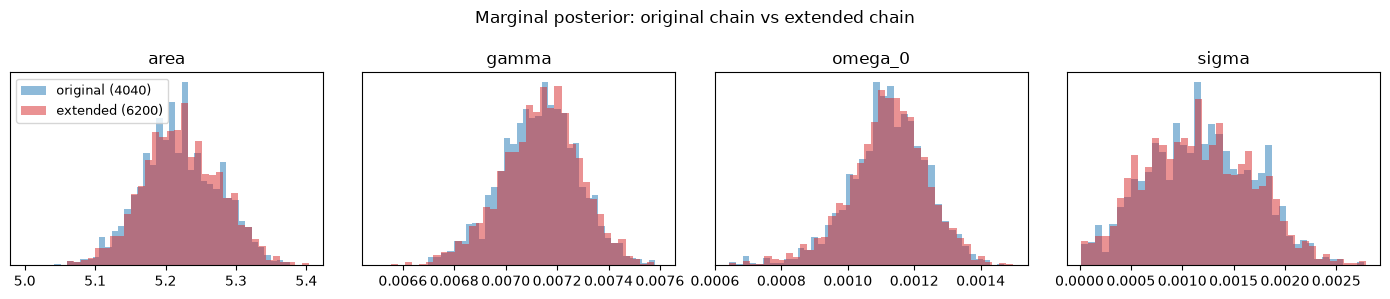

In [17]:
# Visual comparison: overlay the original chain with the extended set.
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, label, par in zip(
    axes, ('area', 'gamma', 'omega_0', 'sigma'), (area, gamma, omega_0, sigma)
):
    c_first = col_orig(par)
    c_full = col_ext(par)
    ax.hist(
        c_first, bins=40, density=True, alpha=0.5, color='C0', label=f'original ({len(c_first)})'
    )
    ax.hist(
        c_full, bins=40, density=True, alpha=0.5, color='C3', label=f'extended ({len(c_full)})'
    )
    ax.set_title(label)
    ax.set_yticks([])
axes[0].legend(fontsize=9)
fig.suptitle('Marginal posterior: original chain vs extended chain')
plt.tight_layout()
plt.show()

### What is Gelman-Rubin R-hat?

DREAM runs many chains in parallel, each started from a different point. The
Gelman-Rubin statistic $\hat{R}$ compares two variance estimates: $W$, the average
variance *within* each chain, and $B$, the variance of the per-chain *means*.

$$
\hat{R} \approx \sqrt{\frac{W + B}{W}}
$$

If all chains sample the same distribution, each chain mean estimates the same
posterior mean with standard error $\sqrt{W/n}$ (for $n$ draws per chain), so
$B \approx W/n$ — negligible next to $W$ — and $\hat{R} \to 1$ as the chains grow.
If the chains are still drifting toward the posterior, or have settled in different
regions of it, their means genuinely disagree, $B$ stays comparable to $W$ or
larger, and $\hat{R}$ sits visibly above 1. (The exact statistic — Gelman & Rubin
1992, which is what ``state.gelman()`` computes — adds finite-sample corrections
to this; the rule-of-thumb thresholds below are unchanged.)

The usual rule of thumb is $\hat{R} < 1.05$ for **every** parameter; above $\approx 1.1$
the chain should be run for longer. Note that $\hat{R} \approx 1$ is *necessary but not
sufficient* for convergence: chains can agree with each other and still have all
missed the same region of the posterior, so read it alongside the trace plots.

Extending a chain should improve convergence, so we print $\hat{R}$ for the original and
the extended chain side by side.

In [18]:
# Convergence diagnostic: Gelman-Rubin R-hat before and after the extension.
# extend() leaves the original chain state untouched, so both can be compared.
rhat_short = results.state.gelman()
rhat_extended = extended_results.state.gelman()

print('Gelman-Rubin R-hat — values < 1.05 indicate convergence:')
print(f'{"parameter":<22s} {"short":>10s} {"extended":>10s}')
print('-' * 46)
for name, r_short, r_ext in zip(extended_results.param_names, rhat_short, rhat_extended):
    status = '✓' if r_ext < 1.05 else '?' if r_ext < 1.1 else '✗'
    print(f'{name:<22s} {r_short:10.4f} {r_ext:10.4f}  {status}')

Gelman-Rubin R-hat — values < 1.05 indicate convergence:
parameter                   short   extended
----------------------------------------------
Parameter_0                1.0298     1.0200  ✓
Parameter_1                1.0442     1.0323  ✓
Parameter_2                1.0254     1.0203  ✓
Parameter_3                1.0477     1.0340  ✓
